# Практическая работа 11: Качество кластеризации | `Hepta`

## 1. Импорты и конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

NOTEBOOK_DIR = Path.cwd()
HEPTA_PATH = NOTEBOOK_DIR / "hepta.csv"

HEPTA_PATH

PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 11 - Качество кластеризации/hepta.csv')

## 2. Описание данных

В практической работе используется benchmark-набор `Hepta`, который ранее применялся в задаче
разделительной кластеризации. Набор представляет собой трехмерную выпуклую структуру с семью
естественными группами наблюдений, что делает его удобным для исследования качества кластеризации
и выбора рационального числа кластеров.

## 3. Загрузка датасета

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Загружает CSV-файл с benchmark-набором данных.

    Parameters
    ----------
    path : Path
        Путь к CSV-файлу с данными.

    Returns
    -------
    pd.DataFrame
        Таблица наблюдений в исходной структуре CSV-файла.
    """
    return pd.read_csv(path)

In [3]:
hepta_df = load_dataset(HEPTA_PATH)

In [4]:
pd.DataFrame(
    [
        {
            "dataset": "Hepta",
            "n_objects": len(hepta_df),
            "n_features": len([column for column in hepta_df.columns if column.startswith("x")]),
            "n_reference_clusters": hepta_df["true_cluster"].nunique(),
        }
    ]
)

,dataset,n_objects,n_features,n_reference_clusters
0,Hepta,212,3,7


In [5]:
hepta_df.head()

,object_id,x1,x2,x3,true_cluster
0,1,-0.0633,0.0277,0.0227,1
1,2,-0.0007,0.0482,0.0692,1
2,3,-0.0608,-0.0091,0.0531,1
3,4,0.0133,-0.0119,0.0553,1
4,5,-0.0545,-0.0038,0.0017,1


In [6]:
hepta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     212 non-null    int64  
 1   x1            212 non-null    float64
 2   x2            212 non-null    float64
 3   x3            212 non-null    float64
 4   true_cluster  212 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 8.4 KB


## 4. Подготовка данных и вспомогательные функции

In [7]:
def standardize_features(
    data: pd.DataFrame,
    feature_columns: list[str],
) -> tuple[pd.DataFrame, StandardScaler]:
    """Стандартизует признаки набора данных.

    Parameters
    ----------
    data : pd.DataFrame
        Исходная таблица наблюдений.
    feature_columns : list[str]
        Список стандартизируемых признаков.

    Returns
    -------
    tuple[pd.DataFrame, StandardScaler]
        Стандартизованная таблица и использованный объект scaler.
    """
    scaler = StandardScaler()
    transformed = data.copy()
    transformed[feature_columns] = scaler.fit_transform(transformed[feature_columns])
    return transformed, scaler

In [8]:
def plot_reference_clusters_3d(
    data: pd.DataFrame,
    feature_columns: list[str],
    labels: np.ndarray,
    figure_title: str,
) -> None:
    """Строит трехмерную диаграмму эталонной кластерной структуры.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для визуализации.
    feature_columns : list[str]
        Используемые признаки.
    labels : np.ndarray
        Метки эталонных кластеров.
    figure_title : str
        Заголовок рисунка.
    """
    figure = plt.figure(figsize=(8, 6))
    axis = figure.add_subplot(111, projection="3d")
    palette = sns.color_palette("tab10", n_colors=12)
    colors = [palette[int(label) % len(palette)] for label in labels]

    axis.scatter(
        data[feature_columns[0]],
        data[feature_columns[1]],
        data[feature_columns[2]],
        c=colors,
        s=20,
        alpha=0.85,
    )
    axis.set_xlabel(feature_columns[0])
    axis.set_ylabel(feature_columns[1])
    axis.set_zlabel(feature_columns[2])
    axis.set_title(figure_title)
    plt.tight_layout()
    plt.show()

In [9]:
def run_kmeans_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    k_values: range,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Выполняет серию запусков алгоритма `k-Means` для набора значений `k`.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для кластеризации.
    feature_columns : list[str]
        Используемые числовые признаки.
    k_values : range
        Последовательность проверяемых значений числа кластеров.
    random_state : int, default=RANDOM_STATE
        Инициализация генератора случайных чисел.

    Returns
    -------
    pd.DataFrame
        Таблица с метриками `inertia`, `silhouette` и вектором меток.
    """
    X = data[feature_columns].to_numpy()
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X)
        rows.append(
            {
                "k": k,
                "labels": labels,
                "inertia": float(model.inertia_),
                "silhouette": float(silhouette_score(X, labels)),
            }
        )
    return pd.DataFrame(rows)

In [10]:
def cross_validate_kmeans(
    data: pd.DataFrame,
    feature_columns: list[str],
    k_values: range,
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Оценивает `k-Means` с помощью кросс-валидации по validation inertia.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для кластеризации.
    feature_columns : list[str]
        Используемые числовые признаки.
    k_values : range
        Последовательность проверяемых значений числа кластеров.
    n_splits : int, default=5
        Число блоков кросс-валидации.
    random_state : int, default=RANDOM_STATE
        Инициализация разбиения на блоки.

    Returns
    -------
    pd.DataFrame
        Таблица со средним и стандартным отклонением validation inertia.
    """
    X = data[feature_columns].to_numpy()
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for k in k_values:
        validation_inertias = []
        for train_index, validation_index in kfold.split(X):
            X_train = X[train_index]
            X_validation = X[validation_index]
            model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
            model.fit(X_train)
            validation_inertias.append(-model.score(X_validation))

        rows.append(
            {
                "k": k,
                "validation_inertia_mean": float(np.mean(validation_inertias)),
                "validation_inertia_std": float(np.std(validation_inertias, ddof=1)),
            }
        )

    return pd.DataFrame(rows)

In [11]:
def plot_metric_curves(
    results: pd.DataFrame,
    x_column: str,
    metric_columns: list[str],
    figure_title: str,
) -> None:
    """Строит кривые метрик качества от управляющего параметра.

    Parameters
    ----------
    results : pd.DataFrame
        Таблица результатов эксперимента.
    x_column : str
        Столбец, откладываемый по оси абсцисс.
    metric_columns : list[str]
        Метрики, визуализируемые на отдельных осях.
    figure_title : str
        Общий заголовок панели графиков.
    """
    figure, axes = plt.subplots(1, len(metric_columns), figsize=(6.0 * len(metric_columns), 4.5))
    if len(metric_columns) == 1:
        axes = [axes]

    for axis, metric_column in zip(axes, metric_columns):
        axis.plot(results[x_column], results[metric_column], marker="o", linewidth=2)
        axis.set_xlabel(x_column)
        axis.set_ylabel(metric_column)
        axis.set_title(f"{metric_column} от {x_column}")

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [12]:
def plot_similarity_matrix_panel(
    data: pd.DataFrame,
    feature_columns: list[str],
    label_pairs: list[tuple[str, np.ndarray]],
    figure_title: str,
) -> None:
    """Строит панель матриц схожести для нескольких значений `k`.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных.
    feature_columns : list[str]
        Используемые числовые признаки.
    label_pairs : list[tuple[str, np.ndarray]]
        Пары вида `(заголовок, метки кластеров)`.
    figure_title : str
        Заголовок панели.
    """
    X = data[feature_columns].to_numpy()
    similarity_matrix = rbf_kernel(X, gamma=1 / len(feature_columns))
    figure, axes = plt.subplots(1, len(label_pairs), figsize=(5.0 * len(label_pairs), 4.5))

    if len(label_pairs) == 1:
        axes = [axes]

    for axis, (title, labels) in zip(axes, label_pairs):
        order = np.argsort(labels, kind="stable")
        ordered_matrix = similarity_matrix[np.ix_(order, order)]
        sns.heatmap(
            ordered_matrix,
            cmap="viridis",
            cbar=axis is axes[-1],
            xticklabels=False,
            yticklabels=False,
            ax=axis,
        )
        axis.set_title(title)

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

### 4.1. Стандартизация признакового пространства набора `Hepta`

In [13]:
hepta_scaled_df, hepta_scaler = standardize_features(hepta_df, ["x1", "x2", "x3"])

### 4.2. Визуальный анализ эталонной кластерной структуры

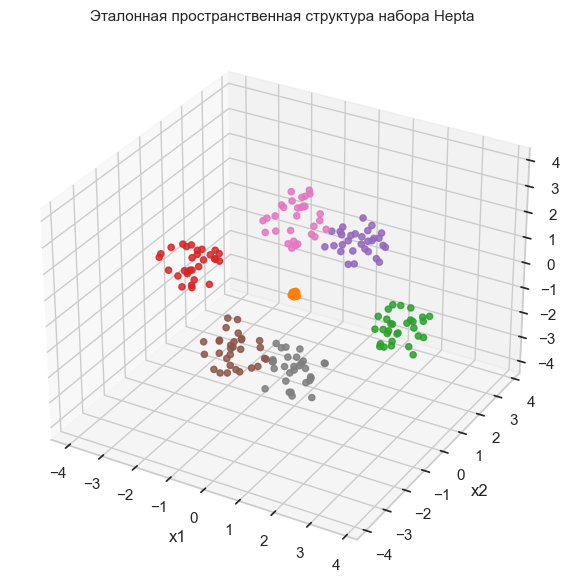

In [14]:
plot_reference_clusters_3d(
    data=hepta_df,
    feature_columns=["x1", "x2", "x3"],
    labels=hepta_df["true_cluster"].to_numpy(),
    figure_title="Эталонная пространственная структура набора Hepta",
)

## 5. Эксперименты

### 5.1. Метод Локтя

Для значений `k` из интервала `3..9` вычисляется `inertia`, то есть сумма квадратов расстояний
наблюдений до центров кластеров. Рациональное число кластеров определяется по излому соответствующей кривой.

In [15]:
hepta_kmeans_results = run_kmeans_grid(hepta_scaled_df, ["x1", "x2", "x3"], range(3, 10))

In [16]:
elbow_table = hepta_kmeans_results[["k", "inertia"]].copy()
elbow_table

,k,inertia
0,3,355.7989
1,4,258.8001
2,5,167.3131
3,6,87.3532
4,7,39.1748
5,8,36.4456
6,9,33.7981


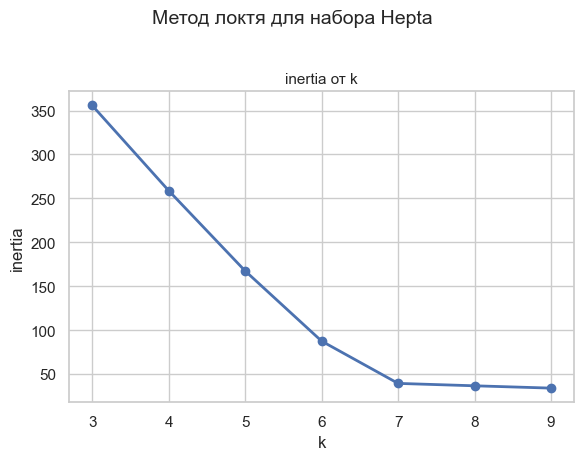

In [17]:
plot_metric_curves(
    results=elbow_table,
    x_column="k",
    metric_columns=["inertia"],
    figure_title="Метод локтя для набора Hepta",
)

### 5.2. Кросс-Валидация

Дополнительно выполняется блочная кросс-валидация. В реализации используется разбиение на несколько блоков; выбрано значение `5` как стандартный компромисс между устойчивостью оценки и размером обучающей выборки. Для каждого значения `k` рассчитывается средняя validation inertia на отложенных блоках и ее разброс, что позволяет оценить устойчивость результата.

In [18]:
cross_validation_table = cross_validate_kmeans(hepta_scaled_df, ["x1", "x2", "x3"], range(3, 10))
cross_validation_table

,k,validation_inertia_mean,validation_inertia_std
0,3,78.4962,7.0790
1,4,59.1457,4.2073
2,5,39.4887,4.1523
3,6,20.7921,2.4936
4,7,8.5657,0.4149
5,8,8.2432,0.4417
6,9,7.8592,0.2588


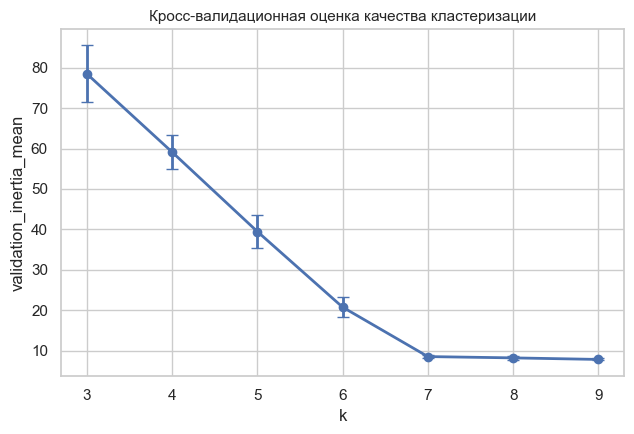

In [19]:
plt.figure(figsize=(6.5, 4.5))
plt.errorbar(
    cross_validation_table["k"],
    cross_validation_table["validation_inertia_mean"],
    yerr=cross_validation_table["validation_inertia_std"],
    marker="o",
    linewidth=2,
    capsize=4,
)
plt.xlabel("k")
plt.ylabel("validation_inertia_mean")
plt.title("Кросс-валидационная оценка качества кластеризации")
plt.tight_layout()
plt.show()

### 5.3. Силуэтный Коэффициент

Для тех же значений `k` вычисляется коэффициент силуэта. Наиболее предпочтительным считается
разбиение, при котором данный коэффициент достигает максимума.

In [20]:
silhouette_table = hepta_kmeans_results[["k", "silhouette"]].copy()
silhouette_table

,k,silhouette
0,3,0.3572
1,4,0.4553
2,5,0.5504
3,6,0.6495
4,7,0.7021
5,8,0.6600
6,9,0.6164


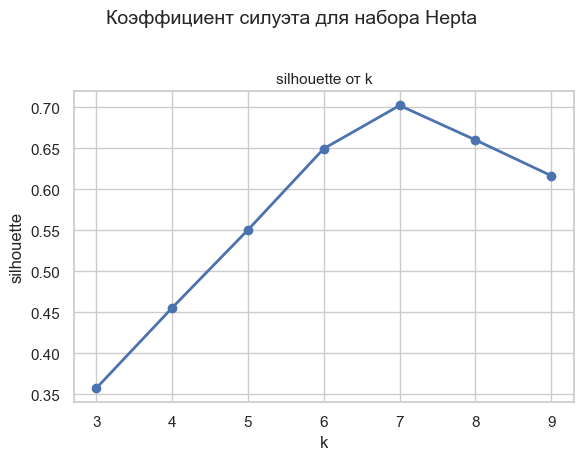

In [21]:
plot_metric_curves(
    results=silhouette_table,
    x_column="k",
    metric_columns=["silhouette"],
    figure_title="Коэффициент силуэта для набора Hepta",
)

In [22]:
silhouette_table.loc[silhouette_table["silhouette"].idxmax(), ["k", "silhouette"]]

k            7.0000
silhouette   0.7021
Name: 4, dtype: float64

### 5.4. Визуализация Матрицы Схожести

Матрица схожести строится для стандартизованных наблюдений с использованием радиально-базисной меры.
Для интерпретации результата строки и столбцы упорядочиваются по меткам кластеров, полученным при `k = 6`, `k = 7` и `k = 8`.

In [23]:
similarity_label_pairs = [
    (f"k = {int(row.k)}", row.labels)
    for row in hepta_kmeans_results.loc[hepta_kmeans_results["k"].isin([6, 7, 8]), ["k", "labels"]].itertuples(index=False)
]

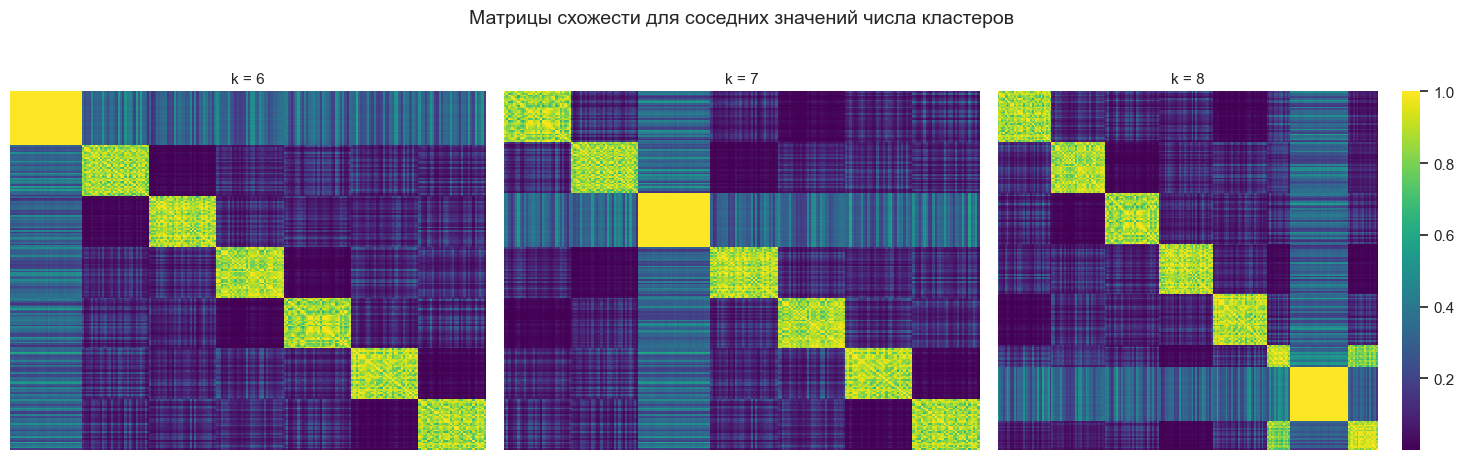

In [24]:
plot_similarity_matrix_panel(
    data=hepta_scaled_df,
    feature_columns=["x1", "x2", "x3"],
    label_pairs=similarity_label_pairs,
    figure_title="Матрицы схожести для соседних значений числа кластеров",
)

## 6. Вывод

Метод локтя показывает выраженный излом кривой `inertia` при `k = 7`. Кросс-валидационная оценка
после `k = 7` продолжает улучшаться уже существенно медленнее. Коэффициент силуэта достигает максимума
при `k = 7`. Визуализация матрицы схожести показывает, что при `k = 6` происходит слияние естественных
блоков, а при `k = 8` один из блоков искусственно расщепляется. Совокупность всех приемов указывает
на рациональность выбора `k = 7` для набора `Hepta`.